In [82]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt

In [83]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

TEST_START = "2025-07-01"
TEST_END = "2026-06-30"

TRAIN = pd.date_range(start=TRAIN_START, end=TRAIN_END)
TEST = pd.date_range(start=TEST_START, end=TEST_END)

In [84]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [85]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [86]:
daily_returns = daily_prices["Close"].pct_change(fill_method=None)
daily_volumes = daily_prices["Volume"]

In [404]:
weight_lag = 5

In [557]:
def featureX(ticker="BTC-USD"):
    df = pd.DataFrame()
    
    # df["7_AVG"] = daily_returns.shift().rolling(7).mean()[ticker]
    df["28_AVG"] = daily_returns.shift().rolling(28).mean()[ticker]
    df["60_AVG"] = daily_returns.shift().rolling(60).mean()[ticker]
    df["28_VOL_RATIO"] = (daily_volumes.shift() / daily_volumes.shift().rolling(28).mean())[ticker]
    df["60_VOL_RATIO"] = (daily_volumes.shift() / daily_volumes.shift().rolling(60).mean())[ticker]
    df["28_MOM"] = daily_returns.shift().rolling(28).mean()[ticker] * (daily_volumes.shift() / daily_volumes.shift().rolling(28).mean())[ticker]
    df["60_MOM"] = daily_returns.shift().rolling(60).mean()[ticker] * (daily_volumes.shift() / daily_volumes.shift().rolling(60).mean())[ticker]
    df["28_STD"] = daily_returns.shift().rolling(28).std()[ticker]
    df["60_STD"] = daily_returns.shift().rolling(60).std()[ticker]
    df["INV_28_STD"] = 1 / daily_returns.shift().rolling(28).std()[ticker]
    df["INV_60_STD"] = 1 / daily_returns.shift().rolling(60).std()[ticker]
    df["WEEKDAY"] = daily_returns.index.weekday.map(lambda x: x in [0, 1, 2, 3, 4]) * 1.0
    df["28_SHARPE"] = daily_returns.shift().rolling(28).mean()[ticker] / daily_returns.shift().rolling(28).std()[ticker]
    df["60_SHARPE"] = daily_returns.shift().rolling(60).mean()[ticker] / daily_returns.shift().rolling(60).std()[ticker]

    if ticker != "BTC-USD":
        df["28_RET_VS_BTC"] = daily_returns.shift().rolling(28).mean()[ticker] - daily_returns.shift().rolling(28).mean()["BTC-USD"]
        df["28_CORR_BTC"] = daily_returns.shift().rolling(28).corr(daily_returns.shift()["BTC-USD"])[ticker]
    if ticker != "ETH-USD":
        df["28_RET_VS_ETH"] = daily_returns.shift().rolling(28).mean()[ticker] - daily_returns.shift().rolling(28).mean()["ETH-USD"]
        df["28_CORR_ETH"] = daily_returns.shift().rolling(28).corr(daily_returns.shift()["ETH-USD"])[ticker]    

    # return df.iloc[:-weight_lag][::weight_lag]
    return df

feature_x = featureX()
feature_x

,28_AVG,60_AVG,28_VOL_RATIO,60_VOL_RATIO,28_MOM,60_MOM,28_STD,60_STD,INV_28_STD,INV_60_STD,WEEKDAY,28_SHARPE,60_SHARPE,28_RET_VS_ETH,28_CORR_ETH
Date,,,,,,,,,,,,,,,
2014-09-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2014-09-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2014-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2014-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2014-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-04,0.002340,0.004919,0.412597,0.423871,0.000966,0.002085,0.020272,0.022368,49.329608,44.705921,0.0,0.115437,0.219899,-0.000737,0.912100
2026-10-05,0.002828,0.005115,0.495742,0.509127,0.001402,0.002604,0.020541,0.022452,48.684209,44.540020,1.0,0.137680,0.227841,-0.000284,0.912968
2026-10-06,0.003090,0.005068,0.989441,1.017600,0.003057,0.005157,0.020346,0.022477,49.150282,44.490527,1.0,0.151880,0.225490,-0.000154,0.913340


In [558]:
daily_returns.index.weekday.map(lambda x: x in [0, 1, 2, 3, 4]) * 1.0

Index([1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0,
       ...
       1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0],
      dtype='float64', name='Date', length=4405)

In [559]:
def featureY(ticker="BTC-USD"):
    # return daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1].iloc[:-weight_lag][::weight_lag]
    return daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1]

feature_y = featureY()
feature_y

Date
2014-09-17         NaN
2014-09-18   -0.122340
2014-09-19    0.033233
2014-09-20    0.074195
2014-09-21    0.010977
                ...   
2026-10-04   -0.020883
2026-10-05         NaN
2026-10-06         NaN
2026-10-07         NaN
2026-10-08         NaN
Freq: D, Name: BTC-USD, Length: 4405, dtype: float64

In [560]:
def Regression(ticker="BTC-USD"):
    X = featureX(ticker).dropna()
    Y = featureY(ticker).dropna()
    
    common_index = X.index.intersection(Y.index)
    regression_model = RollingOLS(Y.loc[common_index], sm.add_constant(X.loc[common_index]), window=360).fit()
    return regression_model

regression_parameters = {
    ticker: Regression(ticker).params.shift(weight_lag).dropna() for ticker in ticker_universe
}

In [571]:
def momentumWeights(DATE_RANGE=TRAIN):
    signal = pd.DataFrame({
        ticker: (sm.add_constant(featureX(ticker)) * regression_parameters[ticker]).sum(axis=1) for ticker in ticker_universe
    })
    ranked = (-signal).rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::weight_lag].reindex(weights.index, method="ffill")
    return lagged_weights

momentum_weights = momentumWeights()
momentum_weights.dropna().loc[TRAIN]

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
2020-01-01,0.035,0.075,0.085,-0.005,-0.035,-0.065,0.015,0.005,-0.075,-0.095,0.065,-0.085,0.025,0.095,-0.035,-0.035,-0.035,0.045,-0.035,0.055
2020-01-02,0.035,0.075,0.085,-0.005,-0.035,-0.065,0.015,0.005,-0.075,-0.095,0.065,-0.085,0.025,0.095,-0.035,-0.035,-0.035,0.045,-0.035,0.055
2020-01-03,0.035,0.075,0.085,-0.005,-0.035,-0.065,0.015,0.005,-0.075,-0.095,0.065,-0.085,0.025,0.095,-0.035,-0.035,-0.035,0.045,-0.035,0.055
2020-01-04,0.025,0.055,0.065,-0.065,-0.025,-0.055,0.015,0.005,0.035,-0.075,0.095,-0.095,-0.085,0.085,-0.025,-0.025,-0.025,0.075,-0.025,0.045
2020-01-05,0.025,0.055,0.065,-0.065,-0.025,-0.055,0.015,0.005,0.035,-0.075,0.095,-0.095,-0.085,0.085,-0.025,-0.025,-0.025,0.075,-0.025,0.045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,0.085,-0.015,0.055,-0.075,-0.095,-0.005,-0.085,0.035,0.075,-0.035,-0.065,-0.045,0.005,-0.025,0.045,-0.055,0.065,0.095,0.015,0.025
2025-06-27,0.085,-0.015,0.055,-0.075,-0.095,-0.005,-0.085,0.035,0.075,-0.035,-0.065,-0.045,0.005,-0.025,0.045,-0.055,0.065,0.095,0.015,0.025
2025-06-28,0.085,-0.015,0.055,-0.075,-0.095,-0.005,-0.085,0.035,0.075,-0.035,-0.065,-0.045,0.005,-0.025,0.045,-0.055,0.065,0.095,0.015,0.025
2025-06-29,0.085,-0.015,0.055,-0.075,-0.095,-0.005,-0.085,0.035,0.075,-0.035,-0.065,-0.045,0.005,-0.025,0.045,-0.055,0.065,0.095,0.015,0.025


In [572]:
def netMomentum(momentum_weights):
    return (momentum_weights * daily_returns).subtract((momentum_weights - momentum_weights.shift()).abs() * 0.002, fill_value=0).sum(axis=1)

train_net_momentum = netMomentum(momentum_weights)[TRAIN]
train_net_momentum.describe()

count    2008.000000
mean        0.000565
std         0.012545
min        -0.083445
25%        -0.004393
50%         0.000097
75%         0.005114
max         0.321599
dtype: float64

In [573]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

<Axes: title={'center': 'Train Momentum Strategy Sharpe (Overall 0.72)'}>

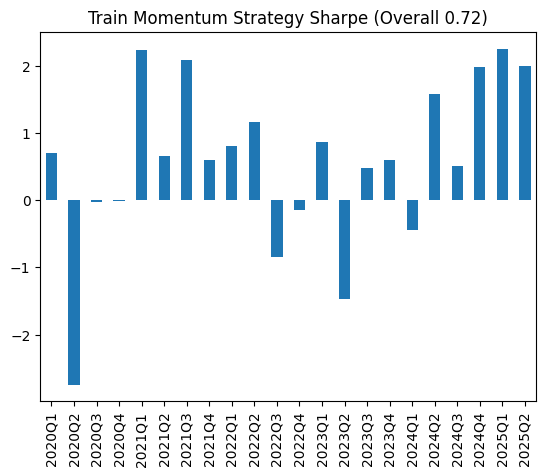

In [574]:
train_net_momentum[TRAIN].resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar", title=f"Train Momentum Strategy Sharpe (Overall {sharpeRatio(train_net_momentum[TRAIN]):.2f})")

<Axes: title={'center': 'Train Momentum Drawdown'}>

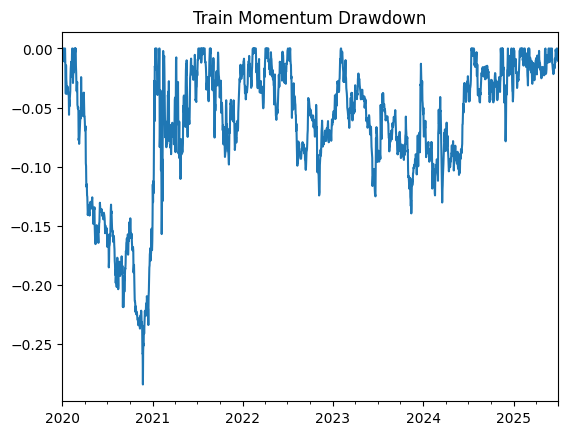

In [575]:
train_drawdown = (1 + train_net_momentum).cumprod() / (1 + train_net_momentum).cumprod().cummax() - 1
train_drawdown.plot(title="Train Momentum Drawdown")